# Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
df_business=pd.read_csv("business_dataset.csv")
df_business.head()

,sku,product_name,category,sub_category,units_sold,unit_price,unit_cost,revenue,margin,discount_pct,channel,region,country,customer_segment,supplier_rating,supplier_grade,inventory_units,review_text,sentiment_label
0,SKU-100000,Prod-8270,Peripherals,General,27,51.68,43.84,1395.36,211.68,0.16,Retail,APAC,India,Enterprise,3.7,B,40.0,NaN,positive
1,SKU-100001,Prod-1860,Gaming,General,23,182.61,156.27,4200.03,605.82,0.25,Retail,EMEA,USA,Small Business,4.1,A,368.0,NaN,positive
2,SKU-100002,Prod-6390,Software,Premium,18,137.94,104.32,2482.92,605.16,0.01,Wholesale,EMEA,Germany,Consumer,3.2,NaN,436.0,NaN,positive
3,SKU-100003,Prod-6191,Office Supplies,Budget,26,207.78,129.96,5402.28,2023.32,0.21,Wholesale,APAC,Brazil,Small Business,3.6,B,NaN,performance average performance poor average p...,neutral
4,SKU-100004,Prod-6734,Peripherals,General,23,311.25,183.52,7158.75,2937.79,0.02,Online,EMEA,UAE,Small Business,4.2,B,476.0,support packaging battery average performance ...,positive


In [3]:
# Get information about the columns in the dataset
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sku               3000 non-null   object 
 1   product_name      3000 non-null   object 
 2   category          3000 non-null   object 
 3   sub_category      3000 non-null   object 
 4   units_sold        3000 non-null   int64  
 5   unit_price        3000 non-null   float64
 6   unit_cost         2765 non-null   float64
 7   revenue           3000 non-null   float64
 8   margin            3000 non-null   float64
 9   discount_pct      2700 non-null   float64
 10  channel           3000 non-null   object 
 11  region            3000 non-null   object 
 12  country           2821 non-null   object 
 13  customer_segment  2767 non-null   object 
 14  supplier_rating   2618 non-null   float64
 15  supplier_grade    2683 non-null   object 
 16  inventory_units   2757 non-null   float64


In [4]:
df_business_num=df_business.select_dtypes(include="number")
df_business_num.describe()

,units_sold,unit_price,unit_cost,revenue,margin,discount_pct,supplier_rating,inventory_units
count,3000.000000,3000.000000,2765.000000,3000.000000,3000.000000,2700.000000,2618.000000,2757.000000
mean,20.001000,198.165680,139.835193,3970.686343,1174.489663,0.123352,3.982506,247.124411
std,4.478655,99.630198,75.294762,2244.845019,819.023113,0.075816,0.644864,147.782892
min,7.000000,16.810000,8.410000,286.400000,63.580000,0.000000,1.500000,0.000000
25%,17.000000,125.937500,86.120000,2403.500000,573.620000,0.070000,3.500000,116.000000
50%,20.000000,181.605000,125.840000,3479.400000,976.250000,0.120000,4.000000,243.000000
75%,23.000000,251.497500,178.400000,5084.212500,1560.910000,0.180000,4.500000,377.000000
max,38.000000,936.230000,576.450000,18295.760000,5905.620000,0.440000,5.000000,499.000000


# Insights from the describe output

In [53]:
df_business_cat=df_business.select_dtypes(include="O")
df_business_cat

,sku,product_name,category,sub_category,channel,region,country,customer_segment,supplier_grade,review_text,sentiment_label
0,SKU-100000,Prod-8270,Peripherals,General,Retail,APAC,India,Enterprise,B,NaN,positive
1,SKU-100001,Prod-1860,Gaming,General,Retail,EMEA,USA,Small Business,A,NaN,positive
2,SKU-100002,Prod-6390,Software,Premium,Wholesale,EMEA,Germany,Consumer,NaN,NaN,positive
3,SKU-100003,Prod-6191,Office Supplies,Budget,Wholesale,APAC,Brazil,Small Business,B,performance average performance poor average p...,neutral
4,SKU-100004,Prod-6734,Peripherals,General,Online,EMEA,UAE,Small Business,B,support packaging battery average performance ...,positive
...,...,...,...,...,...,...,...,...,...,...,...
2995,SKU-102995,Prod-9680,Storage,Budget,Wholesale,Americas,Germany,NaN,B,screen battery screen excellent performance pr...,negative
2996,SKU-102996,Prod-3204,Home Appliances,Air,Retail,Americas,Japan,NaN,A,poor support price value recommended screen fa...,positive
2997,SKU-102997,Prod-6345,Accessories,Premium,Retail,EMEA,France,Corporate,A,reliable excellent durable not durable value d...,positive
2998,SKU-102998,Prod-4276,Storage,Premium,Reseller,EMEA,Brazil,Small Business,C,NaN,negative


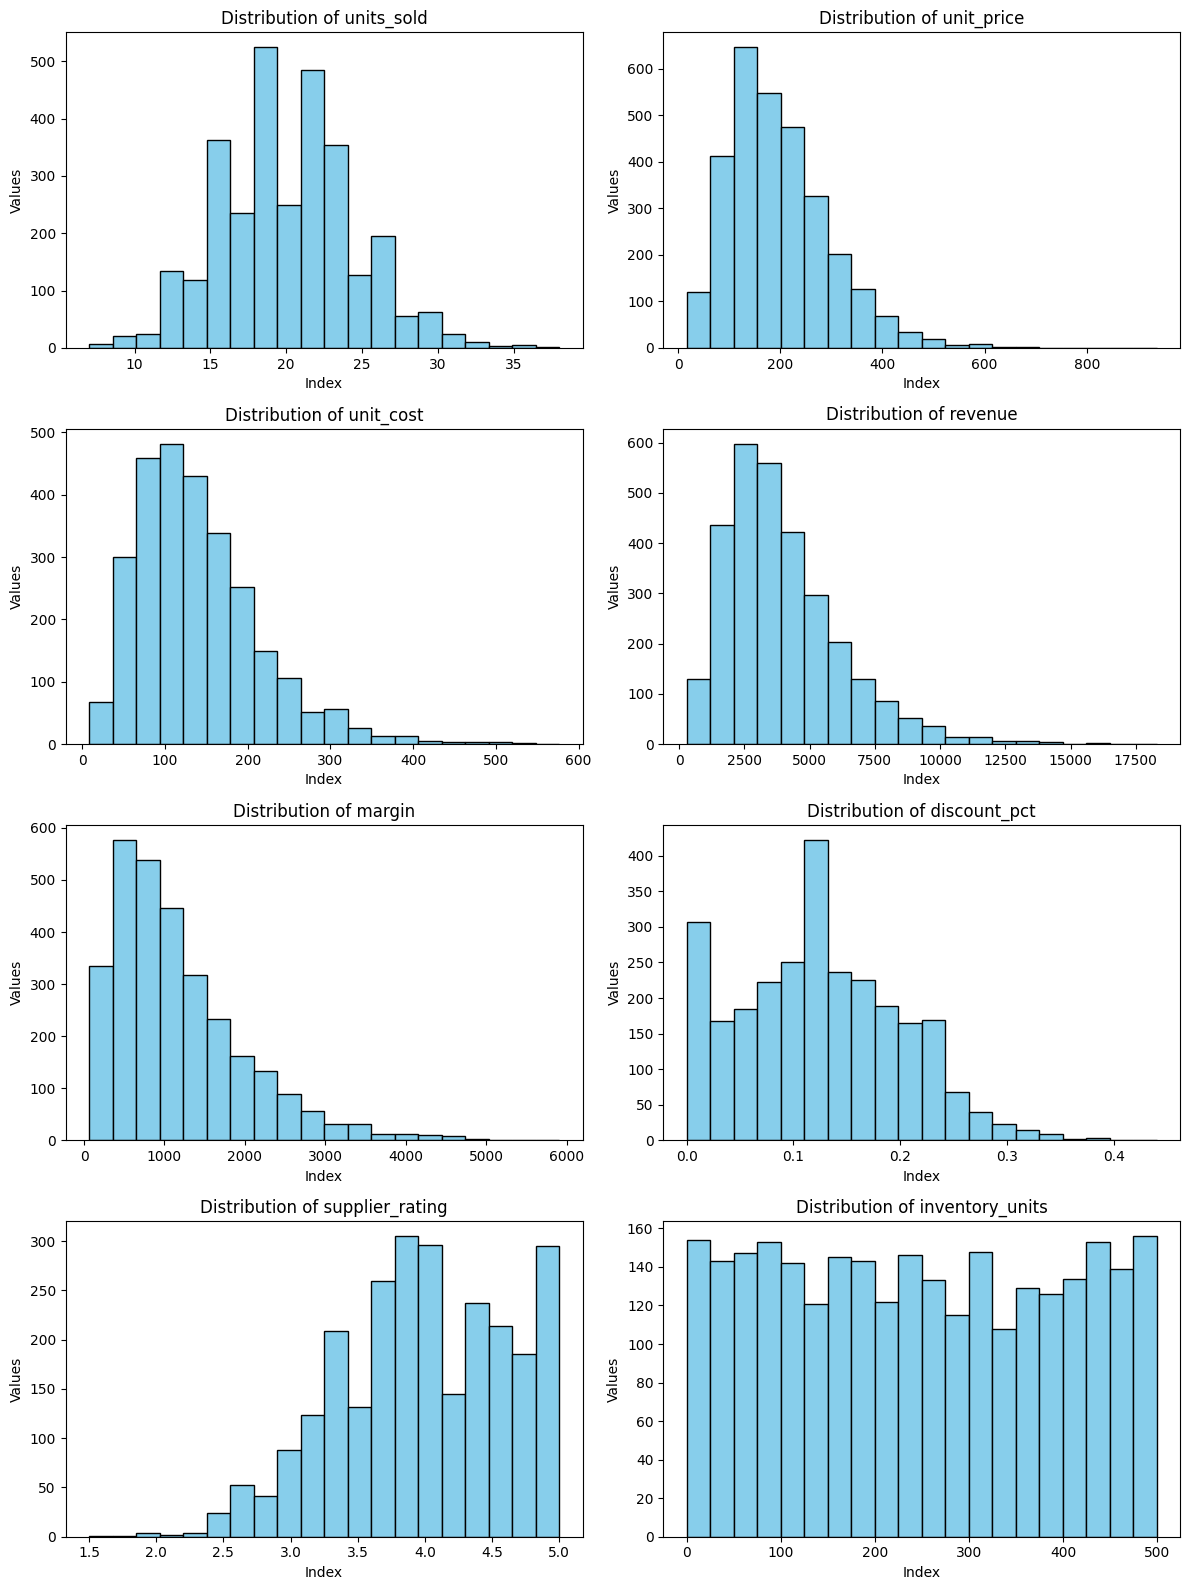

In [6]:
# Prepare charts for numerical columns
fig,axes=plt.subplots(nrows=4,ncols=2,figsize=(12,16))
axes=axes.flatten()

for i,cols in enumerate(df_business_num.columns):
    df_business_num[cols].plot(kind='hist',bins=20,ax=axes[i],color='skyblue',edgecolor='black')
    axes[i].set_title(f"Distribution of {cols}", fontsize=12)
    axes[i].set_xlabel("Index")
    axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()
    

In [7]:
# Find missing values for numeric columns
df_business_num.isnull().sum()

units_sold           0
unit_price           0
unit_cost          235
revenue              0
margin               0
discount_pct       300
supplier_rating    382
inventory_units    243
dtype: int64

In [8]:
df_business_num.isnull().sum()/len(df_business_num)*100

units_sold          0.000000
unit_price          0.000000
unit_cost           7.833333
revenue             0.000000
margin              0.000000
discount_pct       10.000000
supplier_rating    12.733333
inventory_units     8.100000
dtype: float64

In [9]:
df_business_num[df_business_num==0].sum()

units_sold         0.0
unit_price         0.0
unit_cost          0.0
revenue            0.0
margin             0.0
discount_pct       0.0
supplier_rating    0.0
inventory_units    0.0
dtype: float64

In [10]:
# Fixing missing values
# Calculate mean and median for the numeric columns
df_business_num.mean(), df_business_num.median()

(units_sold           20.001000
 unit_price          198.165680
 unit_cost           139.835193
 revenue            3970.686343
 margin             1174.489663
 discount_pct          0.123352
 supplier_rating       3.982506
 inventory_units     247.124411
 dtype: float64,
 units_sold           20.000
 unit_price          181.605
 unit_cost           125.840
 revenue            3479.400
 margin              976.250
 discount_pct          0.120
 supplier_rating       4.000
 inventory_units     243.000
 dtype: float64)

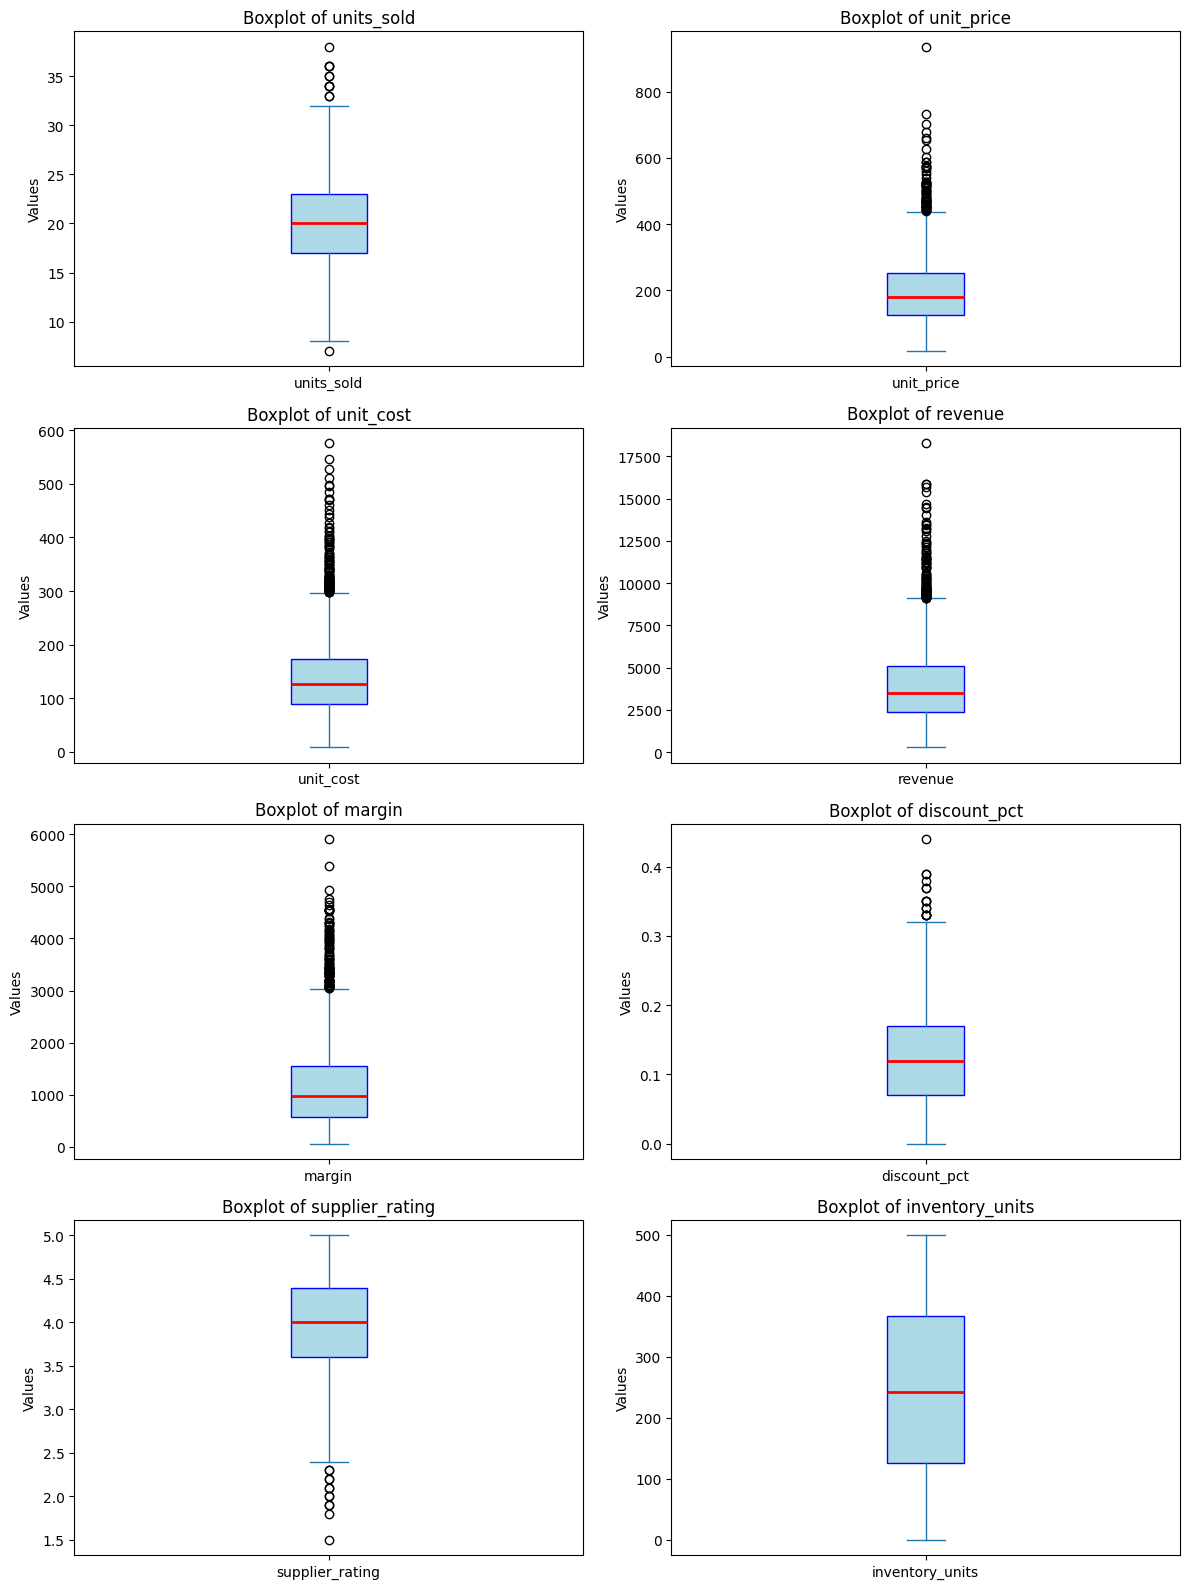

In [96]:
# There is significant differences in the mean and median of revenue and unit_cost.  We need to identify the outliers
# Prepare charts for numerical columns
fig,axes=plt.subplots(nrows=4,ncols=2,figsize=(12,16))
axes=axes.flatten()
for i,cols in enumerate(df_business_num.columns):
    df_business_num[cols].plot(kind='box',ax=axes[i],patch_artist=True, 
                         boxprops=dict(facecolor='lightblue', color='blue'),
                         medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f"Boxplot of {cols}", fontsize=12)
    axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()

In [12]:
# Fixing missing values based on boxplots
df_business_num=df_business_num.fillna(df_business_num.median())
df_business_num.isnull().sum()

units_sold         0
unit_price         0
unit_cost          0
revenue            0
margin             0
discount_pct       0
supplier_rating    0
inventory_units    0
dtype: int64

In [14]:
df_business_num[df_business_num.duplicated()].sum()

units_sold         0.0
unit_price         0.0
unit_cost          0.0
revenue            0.0
margin             0.0
discount_pct       0.0
supplier_rating    0.0
inventory_units    0.0
dtype: float64

# Pair plot the numeric columns to identify the correlation between the columns

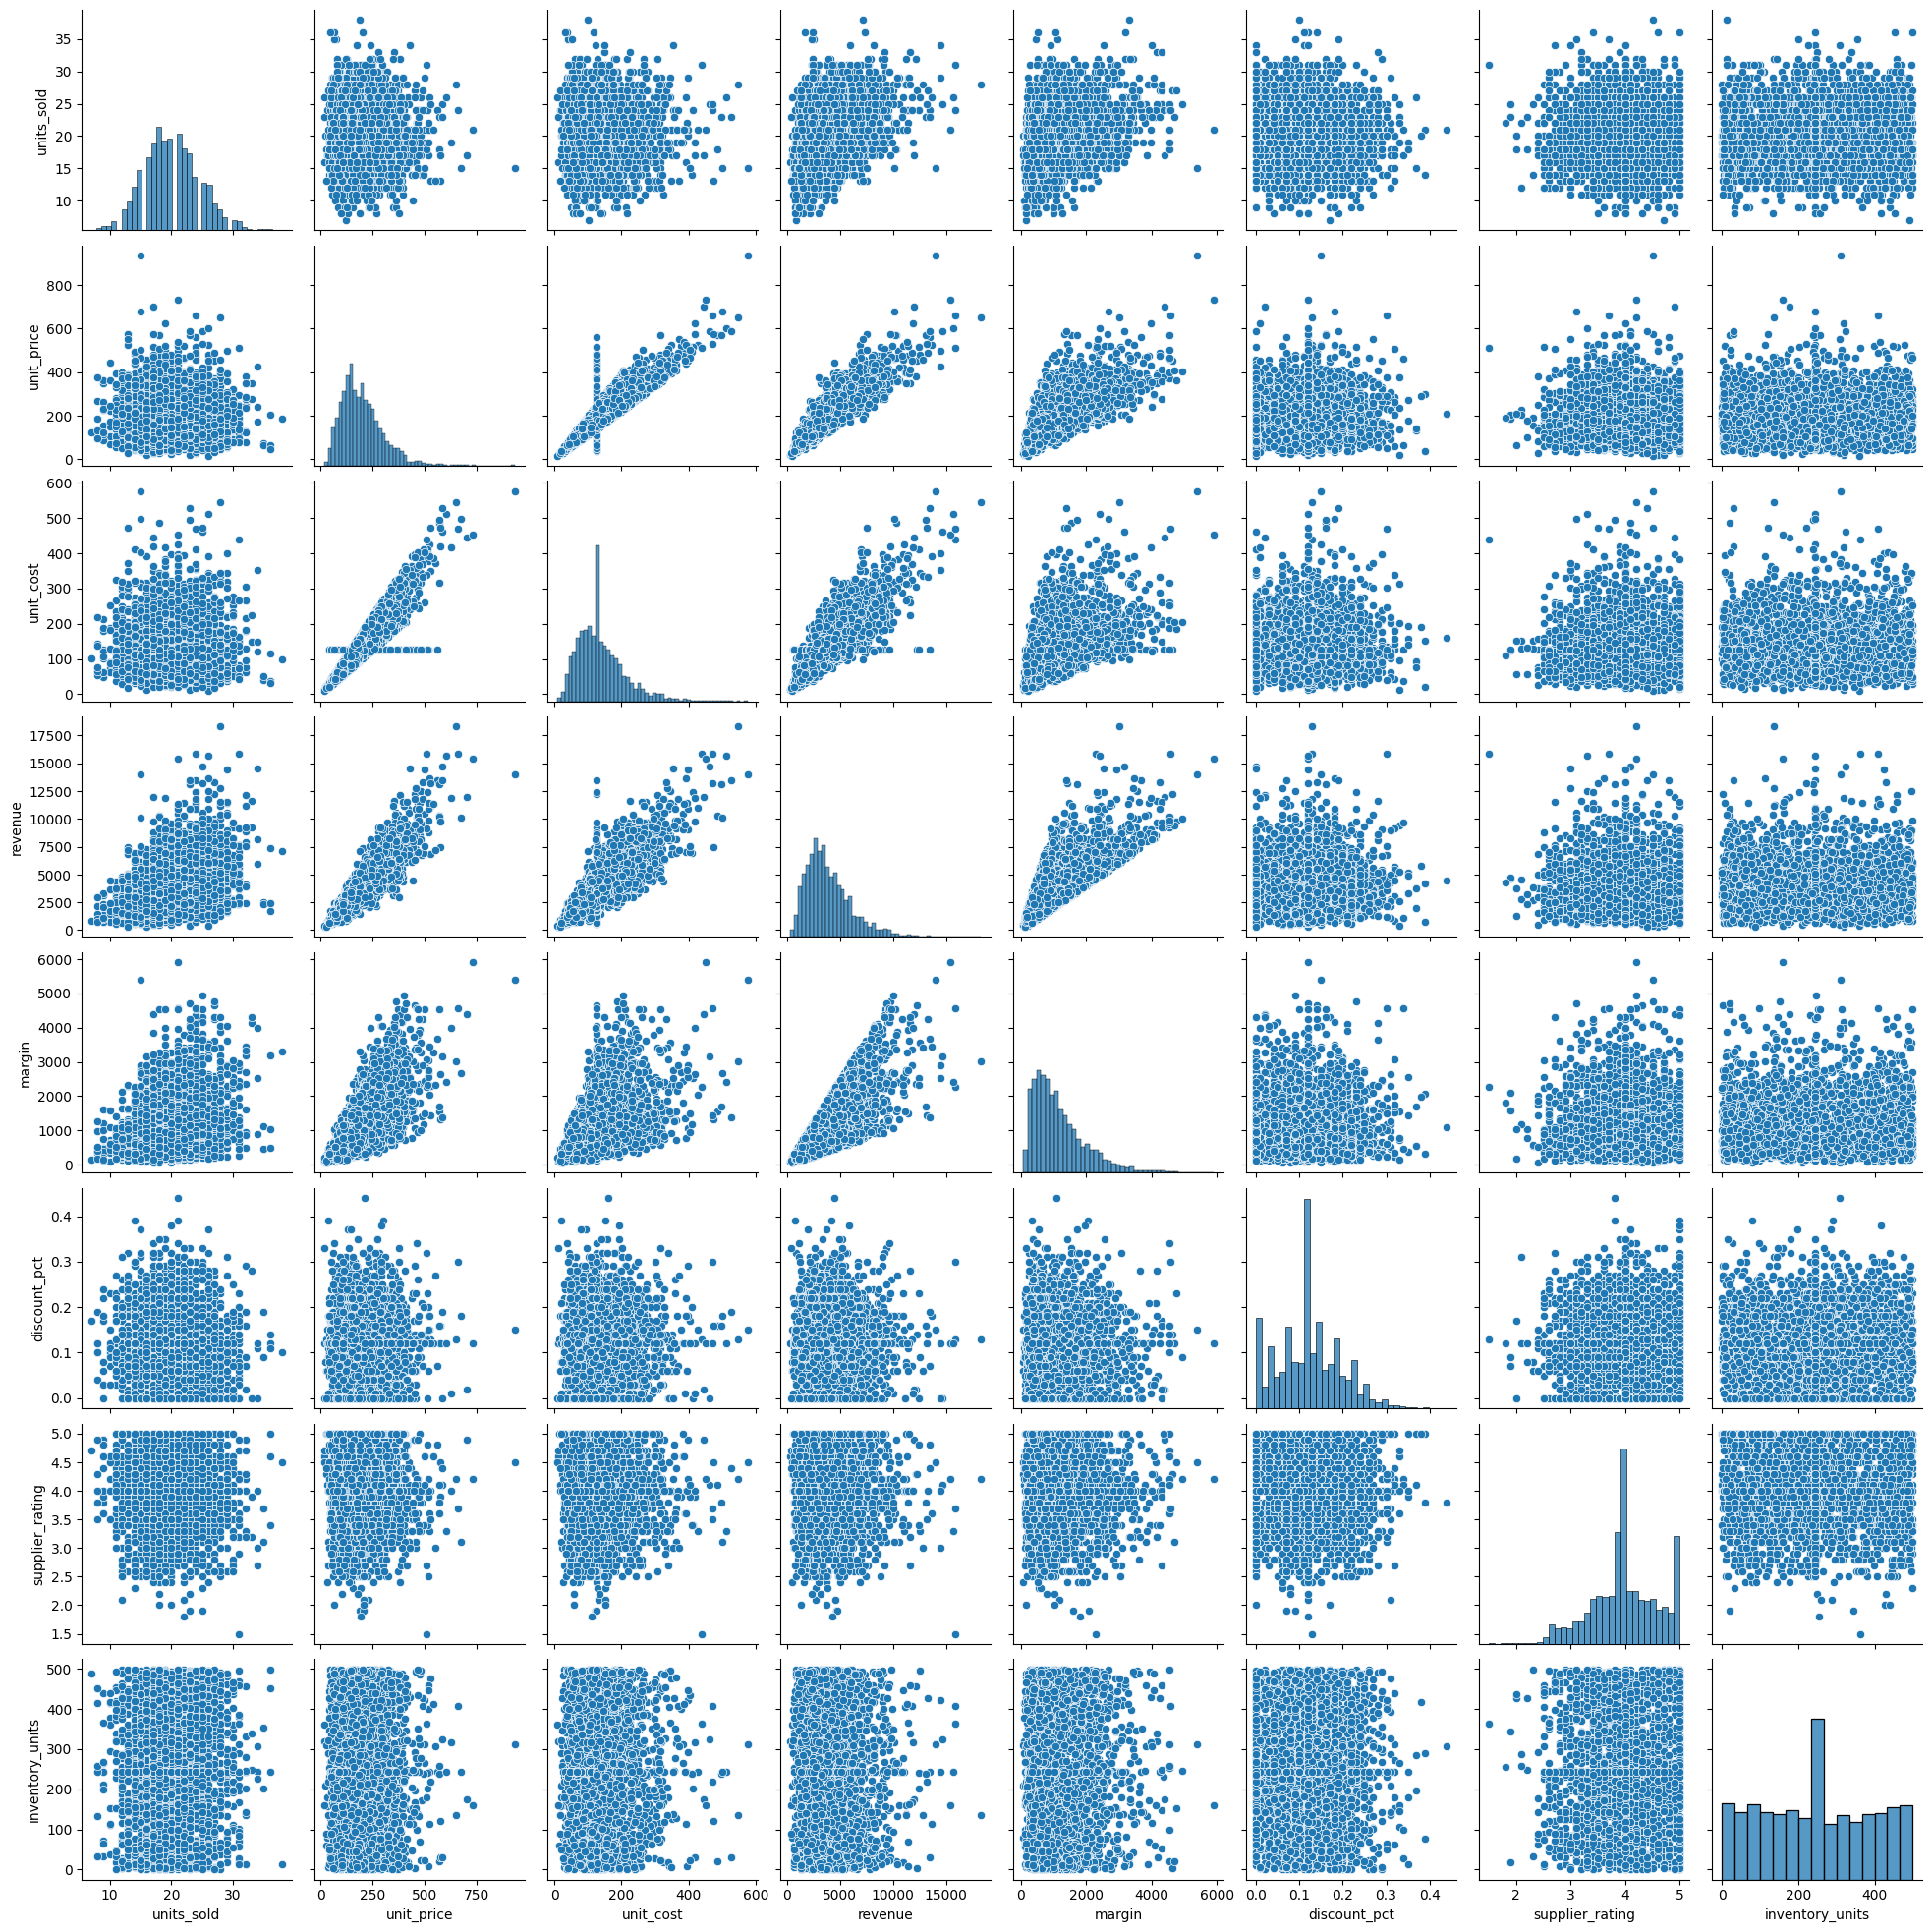

In [15]:
sns.pairplot(df_business_num)
plt.show()

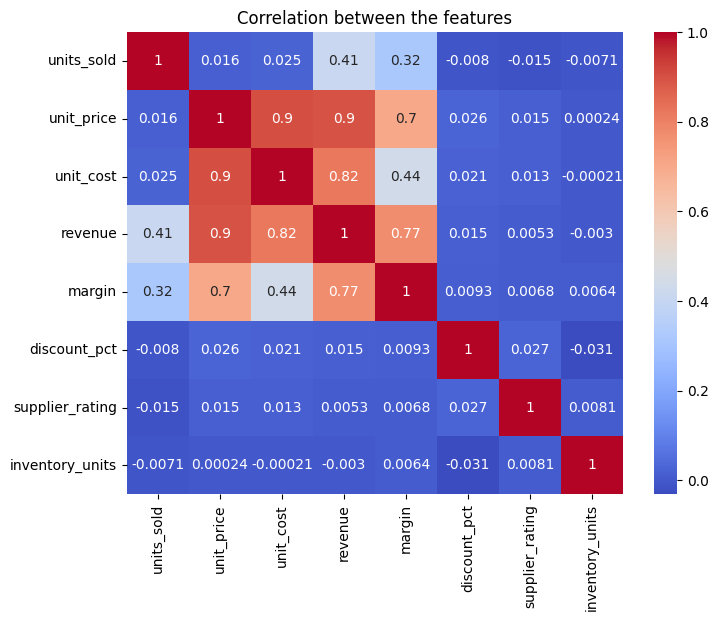

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df_business_num.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation between the features")
plt.show()

In [ ]:
# Leaving space for othere numerical calculation and other findins

<function matplotlib.pyplot.show(close=None, block=None)>

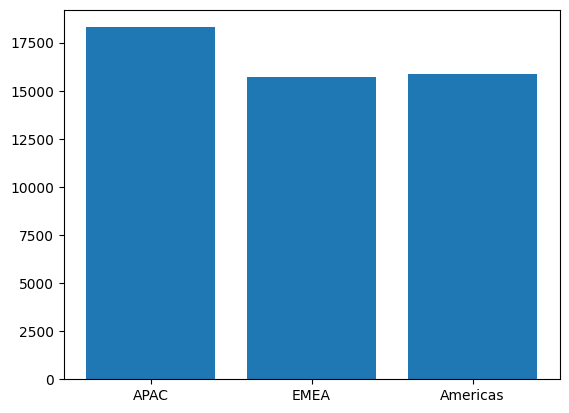

In [78]:
# Ploting graph between region and revenue
plt.bar(df_business_cat.region,df_business_num.revenue)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

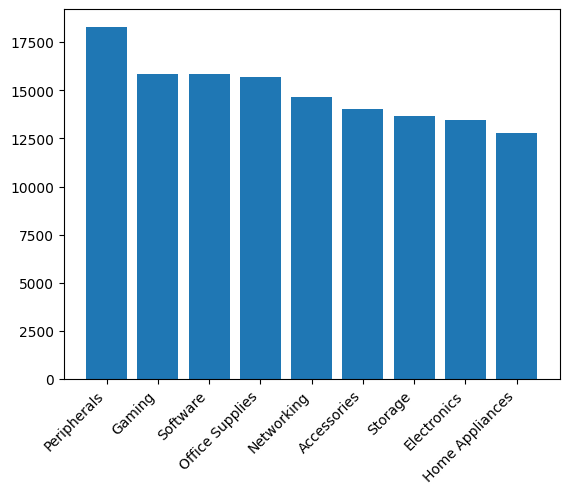

In [91]:
plt.bar(df_business_cat.category,df_revnue_sorted.revenue)
plt.xticks(rotation=45, ha='right')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

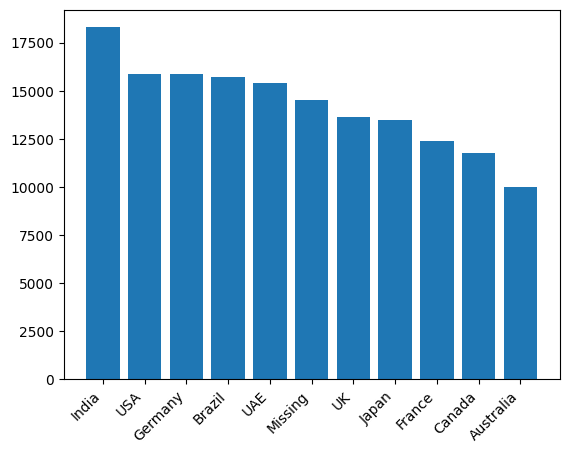

In [95]:
df_revnue_sorted=df_business_num.sort_values("revenue",ascending=False)
plt.bar(df_business_cat.country,df_revnue_sorted.revenue)
plt.xticks(rotation=45, ha='right')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

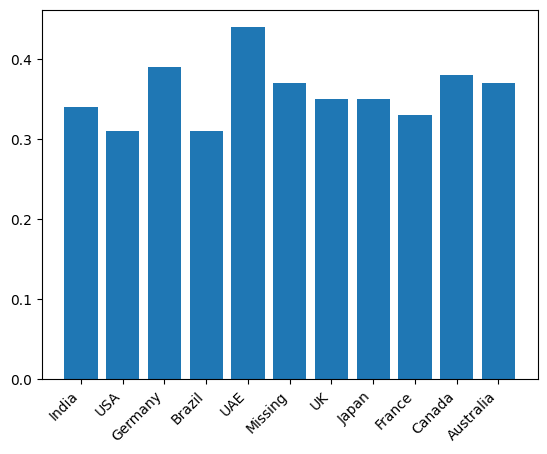

In [94]:
plt.bar(df_business_cat.country,df_revnue_sorted.discount_pct)
plt.xticks(rotation=45, ha='right')
plt.show

In [ ]:
# Categorical data

In [54]:
df_business_cat.head()

,sku,product_name,category,sub_category,channel,region,country,customer_segment,supplier_grade,review_text,sentiment_label
0,SKU-100000,Prod-8270,Peripherals,General,Retail,APAC,India,Enterprise,B,NaN,positive
1,SKU-100001,Prod-1860,Gaming,General,Retail,EMEA,USA,Small Business,A,NaN,positive
2,SKU-100002,Prod-6390,Software,Premium,Wholesale,EMEA,Germany,Consumer,NaN,NaN,positive
3,SKU-100003,Prod-6191,Office Supplies,Budget,Wholesale,APAC,Brazil,Small Business,B,performance average performance poor average p...,neutral
4,SKU-100004,Prod-6734,Peripherals,General,Online,EMEA,UAE,Small Business,B,support packaging battery average performance ...,positive


In [55]:
# Identify the missing values in categorical column
round(df_business_cat.isnull().sum()/len(df_business_cat)*100,2)

sku                  0.00
product_name         0.00
category             0.00
sub_category         0.00
channel              0.00
region               0.00
country              5.97
customer_segment     7.77
supplier_grade      10.57
review_text         40.30
sentiment_label      7.47
dtype: float64

In [56]:
# Review text and sentiment label will be same.  So we can drop review_text.  Later we can use it to check if it matches the sentiment labels or not
df_business_cat=df_business_cat.drop("review_text",axis=1)

In [49]:
df_business_cat.country.unique()

array(['India', 'USA', 'Germany', 'Brazil', 'UAE', nan, 'UK', 'Japan',
       'France', 'Canada', 'Australia'], dtype=object)

In [57]:
df_business_cat.country.fillna("Missing",inplace=True)
df_business_cat.isnull().sum()

C:\Users\lohchs\AppData\Local\Temp\ipykernel_67456\7306214.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_business_cat.country.fillna("Missing",inplace=True)


sku                   0
product_name          0
category              0
sub_category          0
channel               0
region                0
country               0
customer_segment    233
supplier_grade      317
sentiment_label     224
dtype: int64

In [59]:
df_business_cat.customer_segment.unique()

array(['Enterprise', 'Small Business', 'Consumer', 'Corporate', nan],
      dtype=object)

In [60]:
df_business.customer_segment.value_counts()

customer_segment
Consumer          720
Enterprise        694
Small Business    678
Corporate         675
Name: count, dtype: int64

In [61]:
df_business_cat.customer_segment.fillna("Missing",inplace=True)

C:\Users\lohchs\AppData\Local\Temp\ipykernel_67456\2249570705.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_business_cat.customer_segment.fillna("Missing",inplace=True)


In [63]:
df_business_cat.isnull().sum()

sku                   0
product_name          0
category              0
sub_category          0
channel               0
region                0
country               0
customer_segment      0
supplier_grade      317
sentiment_label     224
dtype: int64

In [64]:
df_business_cat.supplier_grade.value_counts()

supplier_grade
B    902
C    893
A    888
Name: count, dtype: int64

In [65]:
df_business_cat.supplier_grade.unique()

array(['B', 'A', nan, 'C'], dtype=object)

In [66]:
df_business_cat.supplier_grade.fillna("Missing",inplace=True)

C:\Users\lohchs\AppData\Local\Temp\ipykernel_67456\410407961.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_business_cat.supplier_grade.fillna("Missing",inplace=True)


In [67]:
df_business_cat.sentiment_label.value_counts()

sentiment_label
positive    1282
negative     939
neutral      555
Name: count, dtype: int64

In [68]:
# As majority of the values are positive, so we will replace the sentiment_label as positive
df_business_cat.sentiment_label.fillna("positive",inplace=True)

C:\Users\lohchs\AppData\Local\Temp\ipykernel_67456\255537242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_business_cat.sentiment_label.fillna("positive",inplace=True)


In [69]:
df_business_cat.sentiment_label.value_counts()

sentiment_label
positive    1506
negative     939
neutral      555
Name: count, dtype: int64

In [71]:
df_business_cat.sentiment_label.isnull().sum()

np.int64(0)

In [72]:
 for feature in df_business_cat:
     print(feature,df_business_cat[feature].unique())

sku ['SKU-100000' 'SKU-100001' 'SKU-100002' ... 'SKU-102997' 'SKU-102998'
 'SKU-102999']
product_name ['Prod-8270' 'Prod-1860' 'Prod-6390' ... 'Prod-6345' 'Prod-4276'
 'Prod-2102']
category ['Peripherals' 'Gaming' 'Software' 'Office Supplies' 'Networking'
 'Accessories' 'Storage' 'Electronics' 'Home Appliances']
sub_category ['General' 'Premium' 'Budget' 'Audio' 'Cleaning' 'Laptops' 'Tablets'
 'Kitchen' 'Air' 'Phones']
channel ['Retail' 'Wholesale' 'Online' 'Reseller']
region ['APAC' 'EMEA' 'Americas']
country ['India' 'USA' 'Germany' 'Brazil' 'UAE' 'Missing' 'UK' 'Japan' 'France'
 'Canada' 'Australia']
customer_segment ['Enterprise' 'Small Business' 'Consumer' 'Corporate' 'Missing']
supplier_grade ['B' 'A' 'Missing' 'C']
sentiment_label ['positive' 'neutral' 'negative']


In [77]:
correlation_index=pd.crosstab(df_business_cat.product_name,df_business_cat.sentiment_label,normalize="columns")
correlation_index

sentiment_label,negative,neutral,positive
product_name,,,
Prod-1001,0.001065,0.0,0.000664
Prod-1004,0.001065,0.0,0.000000
Prod-1005,0.001065,0.0,0.000000
Prod-1006,0.001065,0.0,0.000000
Prod-1007,0.001065,0.0,0.000000
...,...,...,...
Prod-9984,0.001065,0.0,0.000664
Prod-9987,0.000000,0.0,0.000664
Prod-9988,0.000000,0.0,0.000664
